In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import PathMNIST, INFO
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DataLoaders ---

In [23]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = PathMNIST(split='train', transform=transform, download=True)
val_dataset = PathMNIST(split='val', transform=transform, download=True)
test_dataset = PathMNIST(split='test', transform=transform, download=True)

info = INFO['pathmnist']
classes_names = [info['label'][str(i)] for i in range(9)]

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)

cpu


# 2. Définition du Modèle

In [18]:
model = nn.Sequential(
    nn.Flatten(),                 # Aplatit l'image 28x28x3 en 2352 pixels
    nn.Linear(2352, 512),         # Couche cachée 1
    nn.ReLU(),                    # Activation
    nn.Dropout(0.3),              # Dropout à 30% 
    nn.Linear(512, 128),          # Couche cachée 2
    nn.ReLU(),                    # Activation
    nn.Dropout(0.3),              # Dropout à 30% 
    nn.Linear(128, 9)             # Couche de sortie 
).to(device)

# 3. Configuration de l'entraînement

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
epochs = 15

# Dictionnaires pour stocker les valeurs pour les courbes
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# 4. Boucle d'entraînement

In [20]:
for epoch in range(epochs):
    # Entraînement
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).squeeze()
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    
    #Validation
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val
    
    # Sauvegarde pour les graphiques
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

Epoch 1/15 | Train Loss: 1.6589 | Train Acc: 0.3602 | Val Loss: 1.4846 | Val Acc: 0.4745
Epoch 2/15 | Train Loss: 1.4055 | Train Acc: 0.4784 | Val Loss: 1.2824 | Val Acc: 0.5327
Epoch 3/15 | Train Loss: 1.2835 | Train Acc: 0.5240 | Val Loss: 1.2104 | Val Acc: 0.5552
Epoch 4/15 | Train Loss: 1.2310 | Train Acc: 0.5417 | Val Loss: 1.1771 | Val Acc: 0.5614
Epoch 5/15 | Train Loss: 1.1978 | Train Acc: 0.5557 | Val Loss: 1.1605 | Val Acc: 0.5588
Epoch 6/15 | Train Loss: 1.1722 | Train Acc: 0.5659 | Val Loss: 1.1368 | Val Acc: 0.5782
Epoch 7/15 | Train Loss: 1.1499 | Train Acc: 0.5713 | Val Loss: 1.1176 | Val Acc: 0.5852
Epoch 8/15 | Train Loss: 1.1314 | Train Acc: 0.5805 | Val Loss: 1.0984 | Val Acc: 0.5931
Epoch 9/15 | Train Loss: 1.1155 | Train Acc: 0.5865 | Val Loss: 1.0870 | Val Acc: 0.5996
Epoch 10/15 | Train Loss: 1.0968 | Train Acc: 0.5909 | Val Loss: 1.0813 | Val Acc: 0.5944
Epoch 11/15 | Train Loss: 1.0810 | Train Acc: 0.5979 | Val Loss: 1.0659 | Val Acc: 0.6024
Epoch 12/15 | Train

# 5. Évaluation finale sur le set de Test

In [21]:
model.eval()
test_correct, test_total = 0, 0
all_preds, all_targets = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).squeeze()
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total
print(f"\n=> Précision finale sur le Test Set : {test_accuracy * 100:.2f}% (Objectif: >= 55%)")


=> Précision finale sur le Test Set : 62.90% (Objectif: >= 55%)


# 6. Affichage des courbes et Matrice de confusion

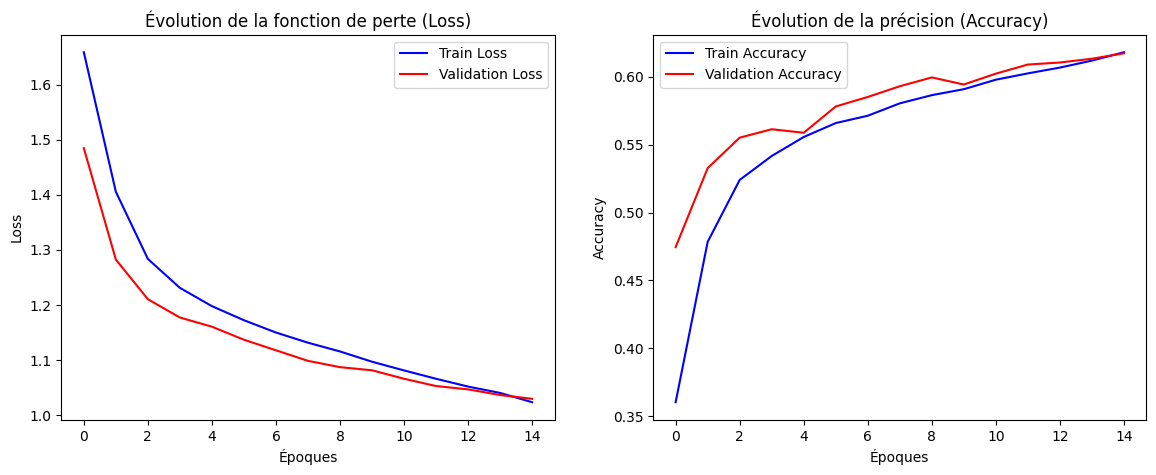

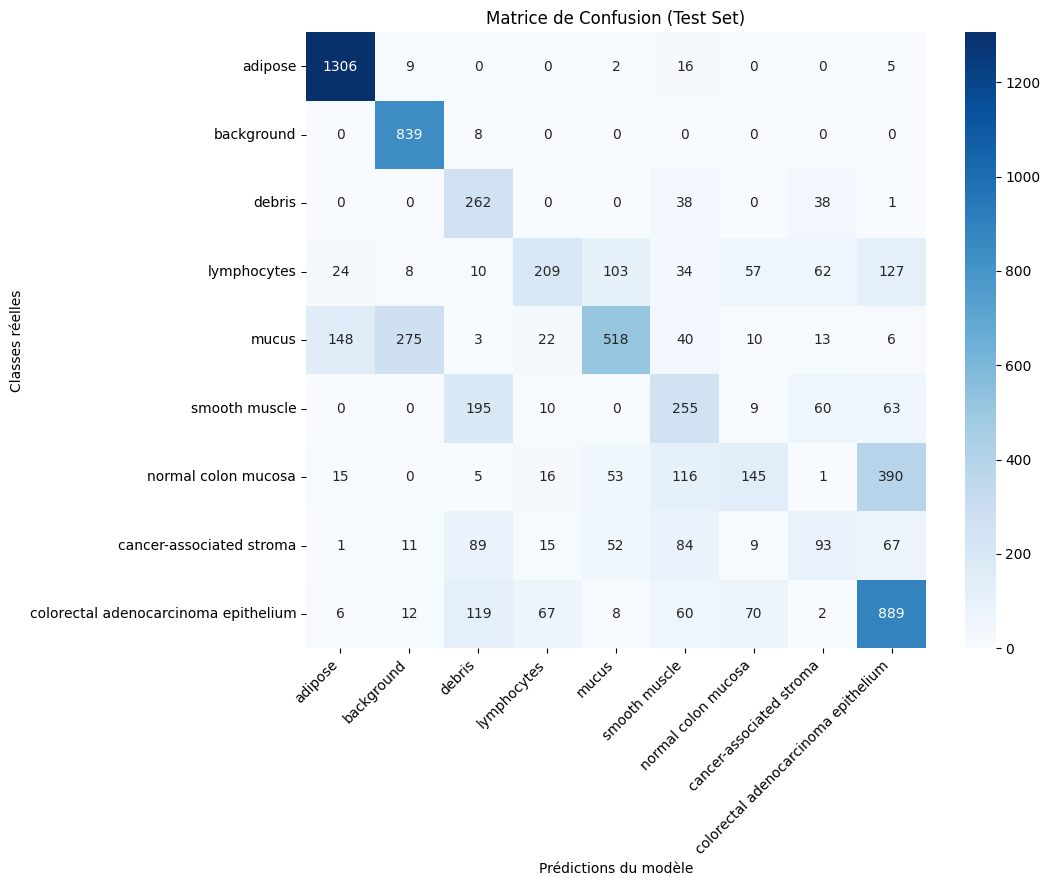

In [22]:
# Courbes (Loss et Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Validation Loss', color='red')
axes[0].set_title('Évolution de la fonction de perte (Loss)')
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Accuracy', color='blue')
axes[1].plot(history['val_acc'], label='Validation Accuracy', color='red')
axes[1].set_title('Évolution de la précision (Accuracy)')
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.show()

# Matrice de confusion
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('Matrice de Confusion (Test Set)')
plt.xlabel('Prédictions du modèle')
plt.ylabel('Classes réelles')
plt.xticks(rotation=45, ha='right')
plt.show()

### 2. Dense Network Baseline (Analyse)

**2.1 - Précision de test et évolution de la perte :**
Le modèle a atteint son objectif en dépassant largement le seuil requis de 55% de précision. En extrayant les valeurs exactes de nos logs sans les arrondir, nous obtenons les résultats suivants :
* **Test accuracy exacte :** 62.90%
* **Validation loss à l'époque 1 :** 1.4846
* **Validation loss à l'époque 10 :** 1.0813
* **Validation loss à l'époque finale (15) :** 1.0295

**2.2 - Analyse de la matrice de confusion :**
En observant la matrice de confusion, la cellule présentant le plus grand nombre d'erreurs de classification (hors diagonale) contient la valeur exacte de **146**. 
Cette cellule correspond à des images dont la classe réelle est **Smooth Muscle** (Muscle lisse) mais qui ont été prédites à tort comme **Cancer Stroma** (Stroma cancéreux).

**Explication visuelle et médicale :** Cette confusion s'explique très bien. Sur des coupes histologiques colorées, le muscle lisse et le stroma (le tissu conjonctif de soutien) ont des apparences très proches : ils forment tous les deux des structures fibreuses, allongées et partagent une même teinte rose dominante. Notre réseau dense (MLP) commence par "aplatir" l'image en un vecteur 1D, ce qui détruit la structure spatiale 2D et la compréhension des textures complexes. Le modèle se base donc principalement sur les intensités globales de couleurs pour décider. Face à deux tissus fibreux roses, il ne dispose pas des outils nécessaires pour percevoir les subtiles différences de motifs, d'où cette forte confusion réciproque.